In [2]:
!pip install qutip matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 33.1 MB/s eta 0:00:00


In [3]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [4]:
sigma_x = sigmax()
sigma_y = sigmay()
sigma_z = sigmaz()
identity = qeye(2)  # Identity matrix for 2-level system

In [5]:
print("Matrix representations:")
print(f"σ_x = {sigma_x}\n")
print(f"σ_y = {sigma_y}\n")
print(f"σ_z = {sigma_z}\n")
print(f"Identity I = {identity}\n")

print("Outer product (ket-bra) representations:")
print("σ_x = |0⟩⟨1| + |1⟩⟨0|")
print("σ_y = -i|0⟩⟨1| + i|1⟩⟨0|")
print("σ_z = |0⟩⟨0| - |1⟩⟨1|")
print("Identity I = |0⟩⟨0| + |1⟩⟨1|")

Matrix representations:
σ_x = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

σ_y = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]

σ_z = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

Identity I = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dia, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]

Outer product (ket-bra) representations:
σ_x = |0⟩⟨1| + |1⟩⟨0|
σ_y = -i|0⟩⟨1| + i|1⟩⟨0|
σ_z = |0⟩⟨0| - |1⟩⟨1|
Identity I = |0⟩⟨0| + |1⟩⟨1|


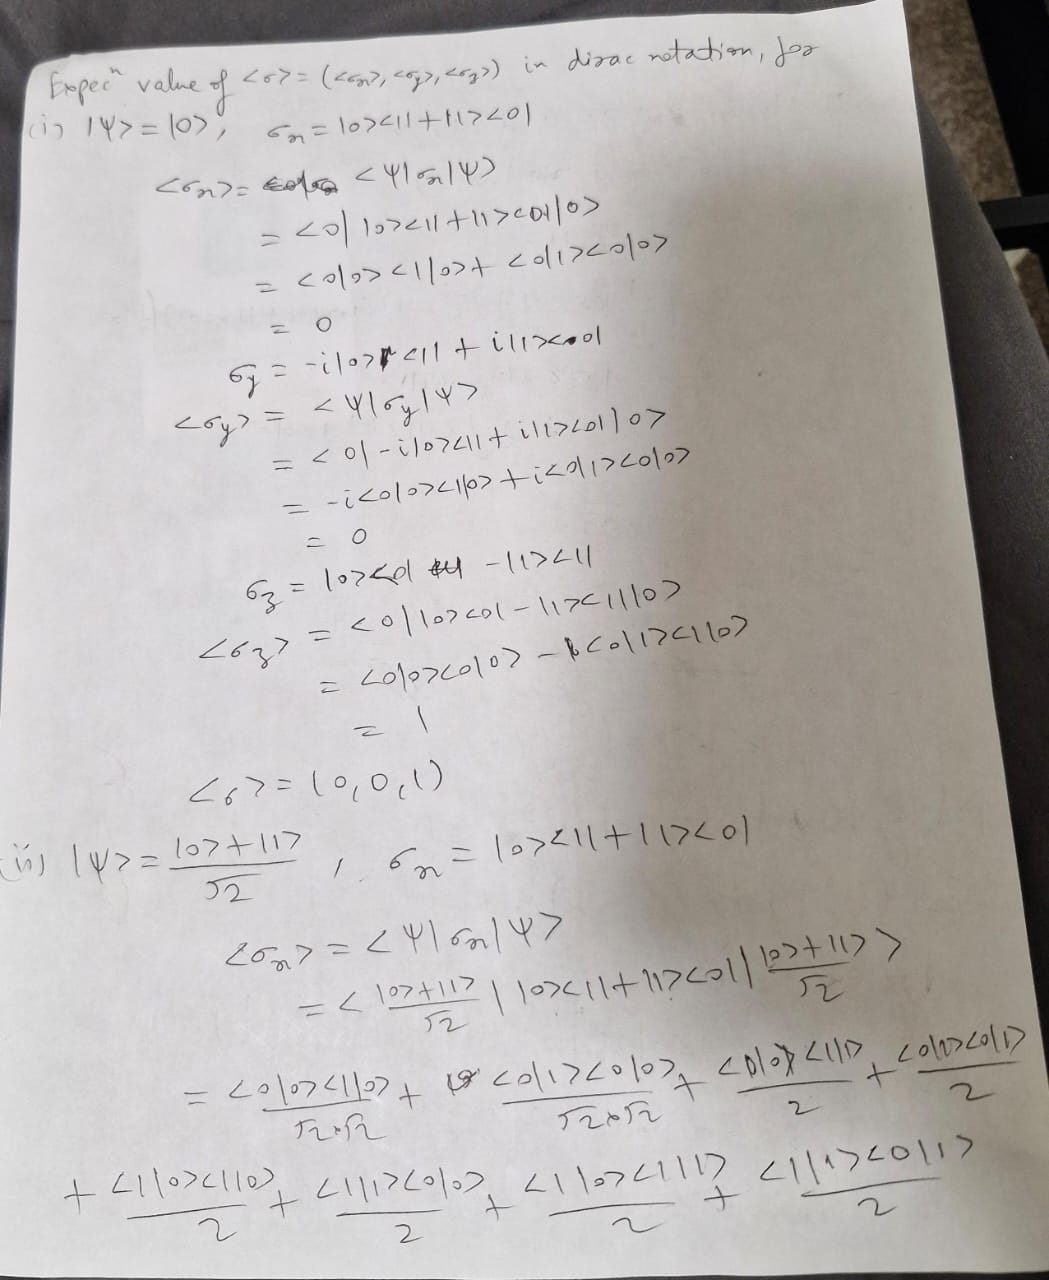

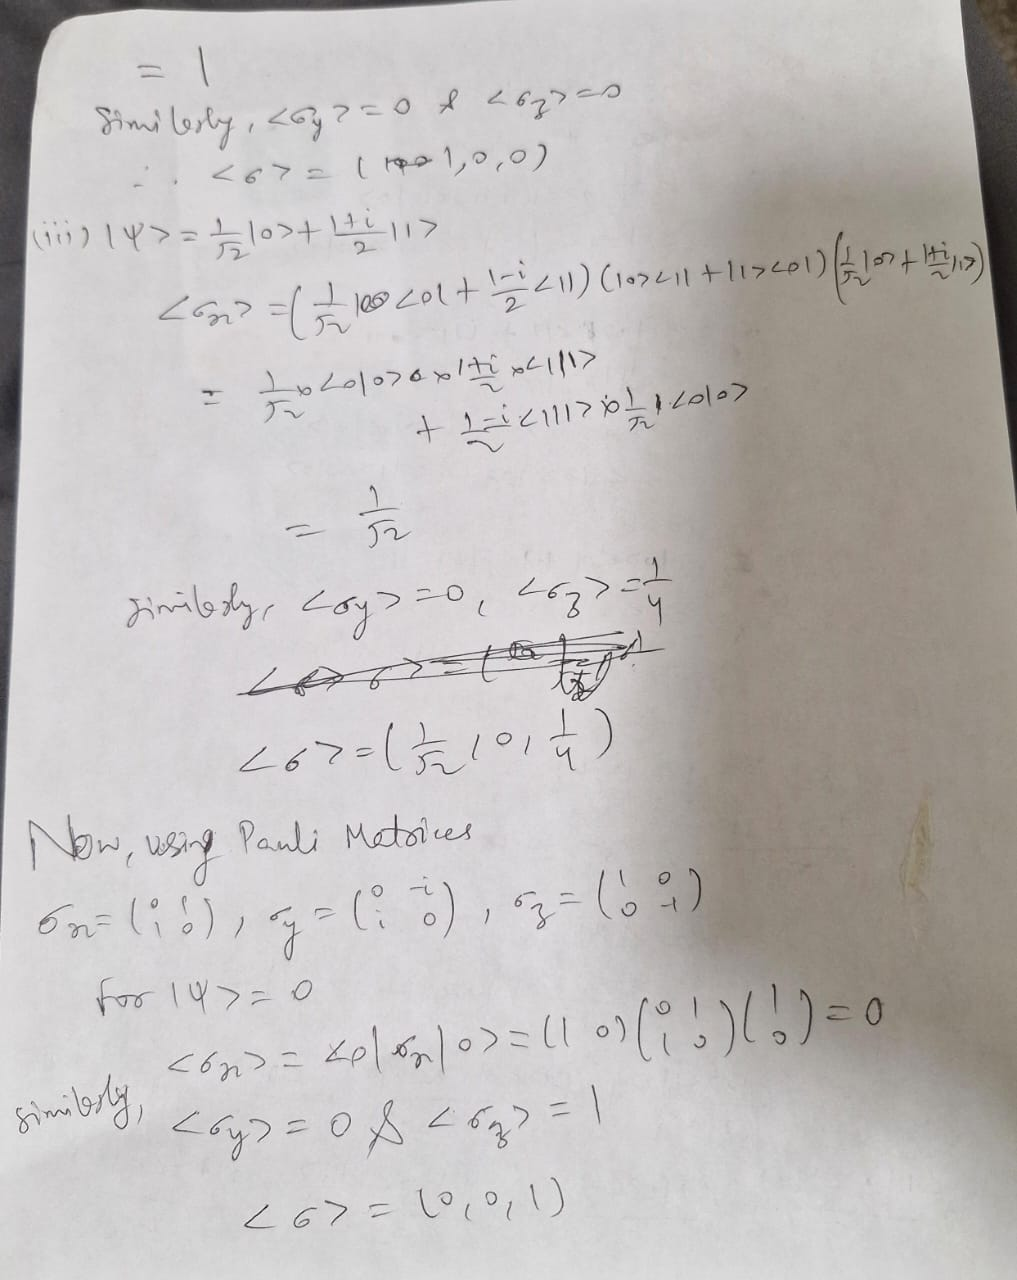

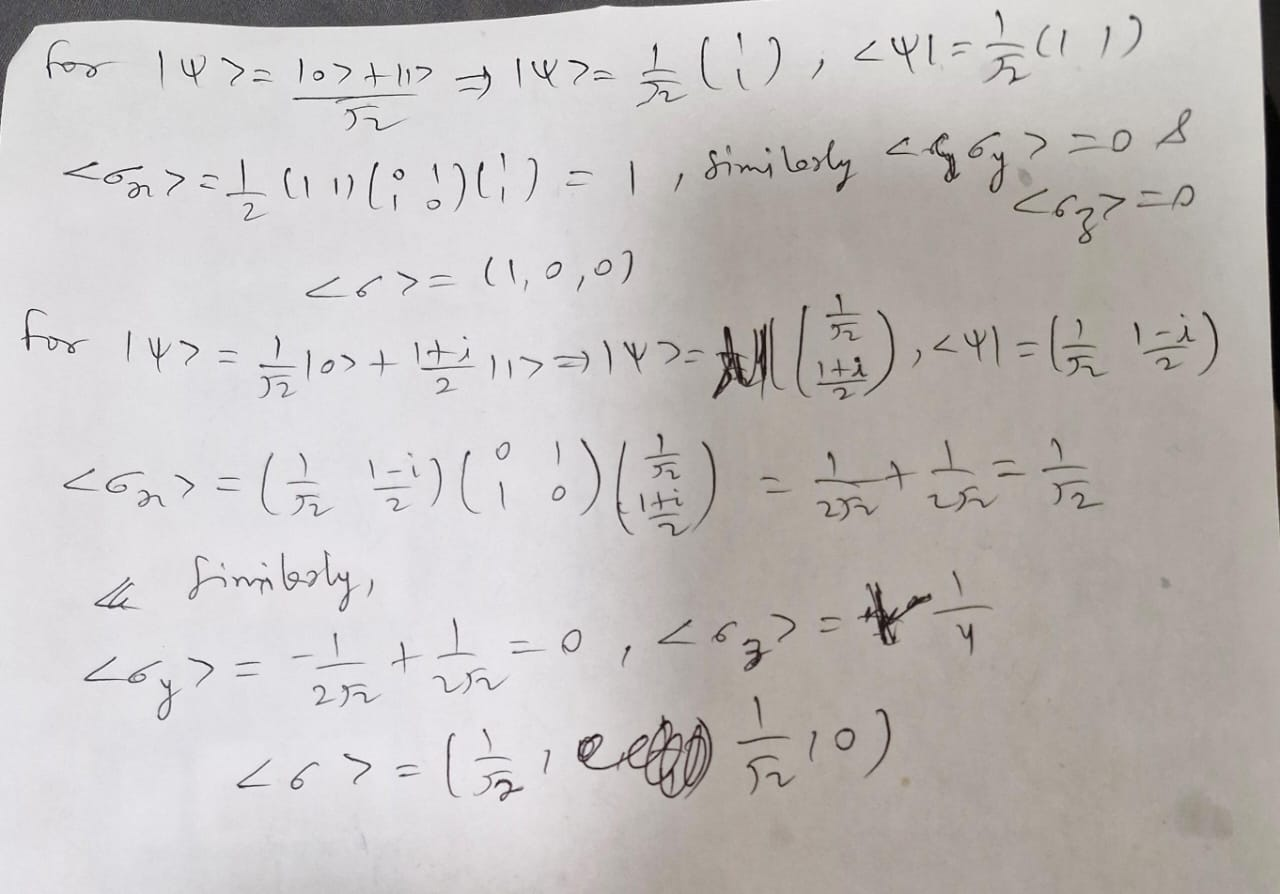

In [29]:
psi1 = basis(2, 0)
psi2 = (basis(2, 0) + basis(2, 1)).unit()
psi3 = (1/np.sqrt(2)) * basis(2, 0) + (1/2) * (1 + 1j) * basis(2, 1)

for i, psi in enumerate([psi1, psi2, psi3]):
    exp_x = expect(sigma_x, psi)
    exp_y = expect(sigma_y, psi)
    exp_z = expect(sigma_z, psi)
    print(f"Expectation values for state ψ{i}:")
    print(f"⟨σx⟩ = {exp_x:.4f}, ⟨σy⟩ = {exp_y:.4f}, ⟨σz⟩ = {exp_z:.4f}\n")

Expectation values for state ψ0:
⟨σx⟩ = 0.0000, ⟨σy⟩ = 0.0000, ⟨σz⟩ = 1.0000

Expectation values for state ψ1:
⟨σx⟩ = 1.0000, ⟨σy⟩ = 0.0000, ⟨σz⟩ = 0.0000

Expectation values for state ψ2:
⟨σx⟩ = 0.7071, ⟨σy⟩ = 0.7071, ⟨σz⟩ = -0.0000



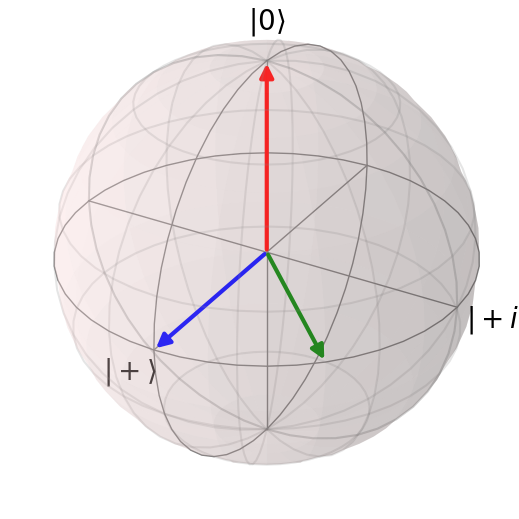

In [7]:
bloch = Bloch()

bloch.add_states(psi1)
bloch.add_states(psi2)
bloch.add_states(psi3)

bloch.vector_color = ['red', 'blue', 'green']

bloch.title = 'Bloch Sphere Visualization of Three States'
bloch.zlabel = ['$|0⟩$', '', '$|1⟩$']
bloch.xlabel = ['$|+⟩$', '', '$|-⟩$']
bloch.ylabel = ['$|+i⟩$', '', '$|-i⟩$']

bloch.show()

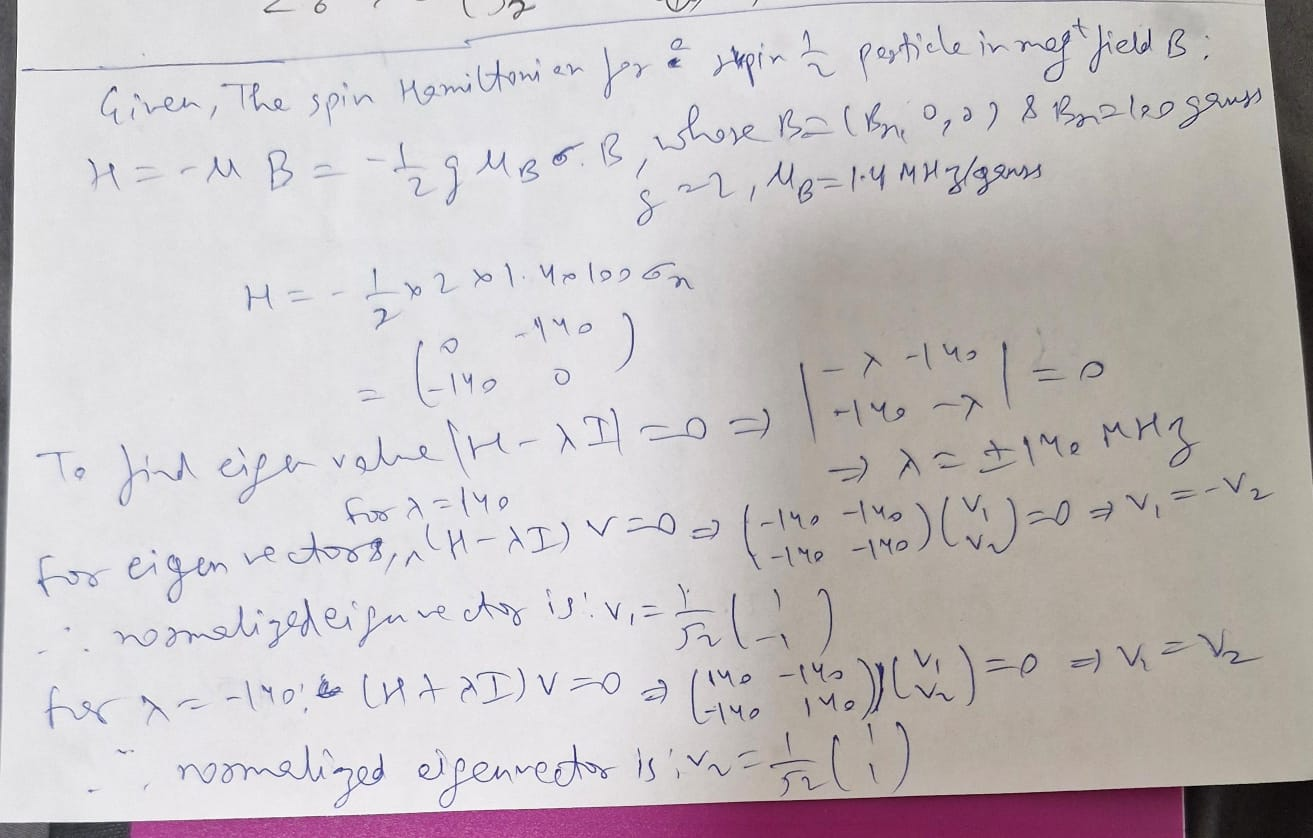

In [8]:
g = 2
mu_B = 1.4e6
B_x = 100

C = -0.5 * g * mu_B * B_x
H = C * sigma_x

eigenvalues, eigenvectors = H.eigenstates()

print("Eigenvalues (in Hz):")
for val in eigenvalues:
    print(f"{val.real:.2f} Hz")

print("\nEigenvectors:")
for vec in eigenvectors:
    print(vec.full())

Eigenvalues (in Hz):
-140000000.00 Hz
140000000.00 Hz

Eigenvectors:
[[-0.70710678+0.j]
 [-0.70710678+0.j]]
[[-0.70710678+0.j]
 [ 0.70710678+0.j]]


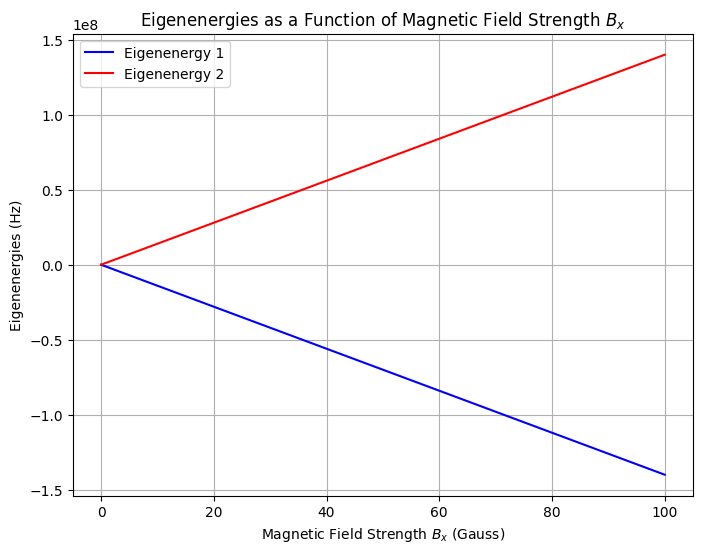

In [9]:
B_x_values = np.linspace(0, 100, 5)
eigenenergy_1 = []
eigenenergy_2 = []
for B_x in B_x_values:
    C = -0.5 * g * mu_B * B_x  # Coefficient of sigma_x
    H = C * sigmax()  # Hamiltonian
    energies = H.eigenenergies()  # Get eigenenergies
    eigenenergy_1.append(energies[0])
    eigenenergy_2.append(energies[1])

plt.figure(figsize=(8, 6))
plt.plot(B_x_values, eigenenergy_1, label="Eigenenergy 1", color="blue")
plt.plot(B_x_values, eigenenergy_2, label="Eigenenergy 2", color="red")
plt.xlabel("Magnetic Field Strength $B_x$ (Gauss)")
plt.ylabel("Eigenenergies (Hz)")
plt.title("Eigenenergies as a Function of Magnetic Field Strength $B_x$")
plt.legend()
plt.grid(True)
plt.show()

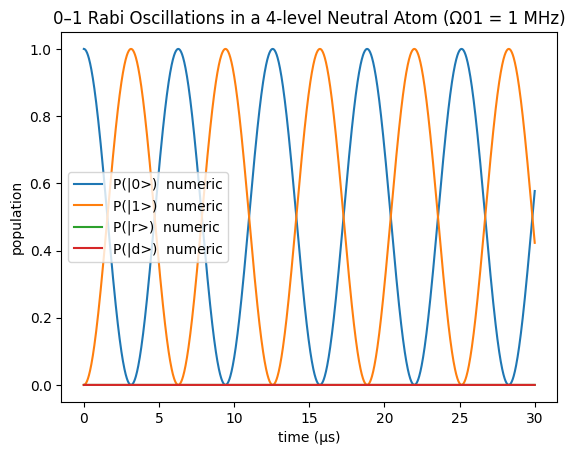

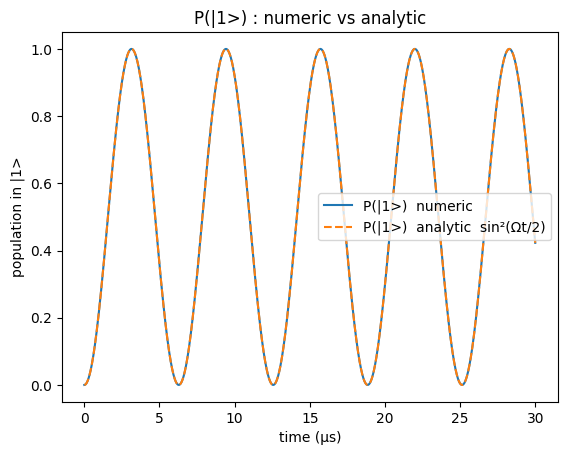

In [33]:
# States: |0>, |1>, |r>, |d>
# Hamiltonian (Eq. 2 with only Ω01 on and all other terms 0):
#   H = (Ω01/2)(|0><1| + |1><0|)
# Lindblad decay from |r> with branching ratios to |0>, |1>, |d|:
#   L_j = sqrt(b_jr * γ_r) |j><r|,  j ∈ {0,1,d}
#
# Units convention:
#   time  in microseconds (µs)
#   Ω, γ  in MHz (= µs^{-1})

# ---------- Parameters (feel free to tweak) ----------
Omega01 = 1.0      # MHz (drive on 0<->1)
delta1  = 0.0      # MHz (detuning of |1>)
Omegar  = 0.0      # MHz (drive on 1<->r) -- OFF for this exercise
Delta_r = 0.0      # MHz (detuning of |r>)

gamma_r = 1.0/5.0  # MHz  => lifetime 5 µs
b0r, b1r, bdr = 1/16, 1/16, 7/8  # branching ratios from |r> to |0|,|1|,|d|

t_max_us = 30.0    # simulate "tens of microseconds"
n_steps  = 1500
tlist = np.linspace(0.0, t_max_us, n_steps)  # µs

# ---------- Basis and projectors ----------
# Index mapping: 0->|0>, 1->|1>, 2->|r>, 3->|d>
ket0 = basis(4, 0)
ket1 = basis(4, 1)
ketr = basis(4, 2)
ketd = basis(4, 3)

P0 = ket0*ket0.dag()
P1 = ket1*ket1.dag()
Pr = ketr*ketr.dag()
Pd = ketd*ketd.dag()

# Transitions
sigma01 = ket0*ket1.dag() + ket1*ket0.dag()   # |0><1| + |1><0|
sigma1r = ket1*ketr.dag() + ketr*ket1.dag()   # |1><r| + |r><1|

# ---------- Hamiltonian ----------
# With only Ω01 nonzero, H reduces to simple 0-1 Rabi coupling.
# (Terms with delta1, Omegar, Delta_r are kept for completeness)
H = 0.5*Omega01 * sigma01 \
    + delta1 * P1 \
    + 0.5*Omegar * sigma1r \
    + Delta_r * Pr

# ---------- Collapse/Lindblad operators ----------
# Even though Ω_r = 0 here (no population should reach |r>),
# we include physical decay pathways for completeness.
c_ops = [
    np.sqrt(b0r * gamma_r) * (ket0*ketr.dag()),  # |r> -> |0>
    np.sqrt(b1r * gamma_r) * (ket1*ketr.dag()),  # |r> -> |1>
    np.sqrt(bdr * gamma_r) * (ketd*ketr.dag()),  # |r> -> |d>
]

# ---------- Initial state ----------
rho0 = P0  # start in |0>

# ---------- Solve master equation ----------
sol = mesolve(
    H, rho0, tlist, c_ops=c_ops,
    e_ops=[P0, P1, Pr, Pd]  # track populations
)

p0, p1, pr, pd = sol.expect  # arrays over time

# ---------- Analytic P1(t) for comparison ----------
# For a pure two-level 0–1 drive with Ω01 and zero detuning:
#   P1(t) = sin^2(Ω01 * t / 2)  (with t in µs and Ω01 in MHz)
p1_analytic = np.sin(0.5 * Omega01 * tlist)**2

# ---------- Plot ----------
plt.figure()
plt.plot(tlist, p0, label="P(|0>)  numeric")
plt.plot(tlist, p1, label="P(|1>)  numeric")
plt.plot(tlist, pr, label="P(|r>)  numeric")
plt.plot(tlist, pd, label="P(|d>)  numeric")
plt.xlabel("time (µs)")
plt.ylabel("population")
plt.title("0–1 Rabi Oscillations in a 4-level Neutral Atom (Ω01 = 1 MHz)")
plt.legend()

# Separate plot to compare P1 numeric vs analytic (clean overlay)
plt.figure()
plt.plot(tlist, p1, label="P(|1>)  numeric")
plt.plot(tlist, p1_analytic, linestyle="--", label="P(|1>)  analytic  sin²(Ωt/2)")
plt.xlabel("time (µs)")
plt.ylabel("population in |1>")
plt.title("P(|1>) : numeric vs analytic")
plt.legend()

plt.show()

Observation from the plot. The numerically computed P∣1⟩(t) lies on top of the analytic sin^2(Ω𝑡/2)curve: peaks stay near 1, minima near 0, and the period is constant T=2π/Ω. No decay is visible—the dynamics are those of an ideal coherent Rabi oscillation.

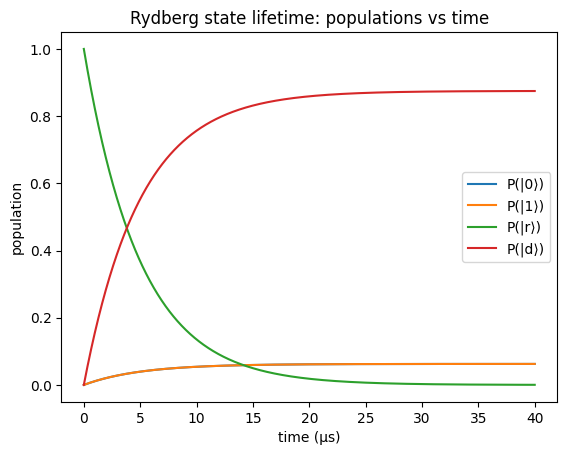

In [5]:
# Model: four levels |0>, |1>, |r>, |d>
# H = 0 (no drives, no detunings)
# Collapse ops: L_j = sqrt(b_jr * gamma_r) |j><r|, j in {0,1,d}
# Units: time in microseconds (µs); rates in MHz (= µs^{-1})

# ---------- Parameters ----------
gamma_r = 1.0/5.0          # MHz  (lifetime 5 µs)
b0r, b1r, bdr = 1/16, 1/16, 7/8

t_max_us = 40.0            # "tens of microseconds"
n_steps  = 1600
tlist = np.linspace(0.0, t_max_us, n_steps)  # µs

# ---------- Basis states ----------
# Index map: 0->|0>, 1->|1>, 2->|r>, 3->|d>
ket0 = basis(4, 0)
ket1 = basis(4, 1)
ketr = basis(4, 2)
ketd = basis(4, 3)

P0 = ket0*ket0.dag()
P1 = ket1*ket1.dag()
Pr = ketr*ketr.dag()
Pd = ketd*ketd.dag()

# ---------- Hamiltonian ----------
# All parameters in Eq. (2) set to zero ⇒ H = 0
H = 0 * P0

# ---------- Lindblad (decay) operators ----------
c_ops = [
    np.sqrt(b0r * gamma_r) * (ket0*ketr.dag()),  # |r> -> |0>
    np.sqrt(b1r * gamma_r) * (ket1*ketr.dag()),  # |r> -> |1>
    np.sqrt(bdr * gamma_r) * (ketd*ketr.dag()),  # |r> -> |d>
]

# ---------- Initial state ----------
rho0 = Pr  # start entirely in |r>

# ---------- Evolve ----------
sol = mesolve(H, rho0, tlist, c_ops=c_ops, e_ops=[P0, P1, Pr, Pd])
p0, p1, pr, pd = sol.expect

# ---------- Plots ----------
# 1) Populations of all four levels
plt.figure()
plt.plot(tlist, p0, label="P(|0⟩)")
plt.plot(tlist, p1, label="P(|1⟩)")
plt.plot(tlist, pr, label="P(|r⟩)")
plt.plot(tlist, pd, label="P(|d⟩)")
plt.xlabel("time (µs)")
plt.ylabel("population")
plt.title("Rydberg state lifetime: populations vs time")
plt.legend()

∣r⟩ decays mono-exponentially with lifetime τ=5μs:

Pr(t)=e−t/τ.

∣d⟩ increases as Pd(t)=7/8(1−e−t/τ) and saturates at 7/8≈0.875.

∣1⟩ increases as P1(t)=1/16(1−e−t/τ) and saturates at 1/16≈0.0625.

∣0⟩ increases as P0(t)=1/16(1−e−t/τ) and also saturates at 1/16≈0.0625.


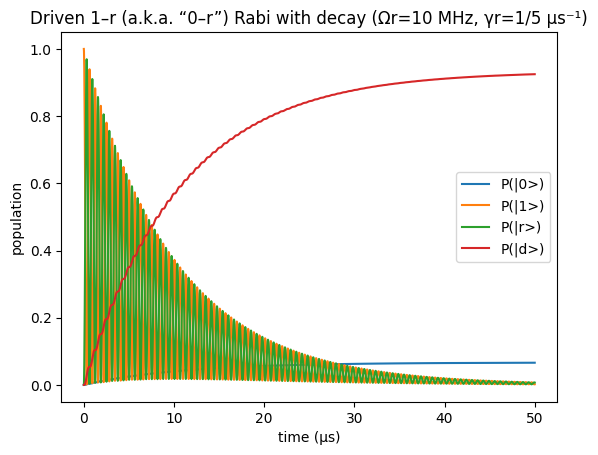

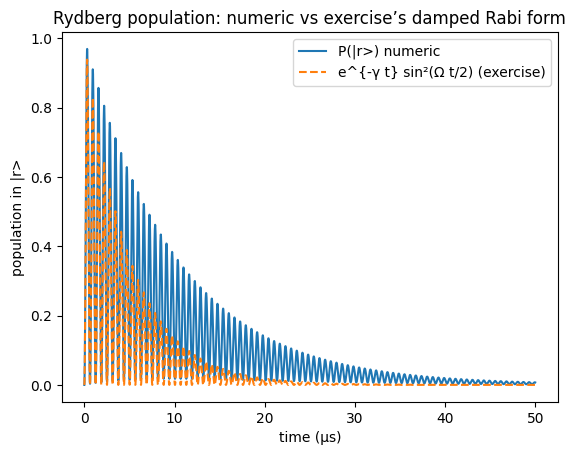

In [7]:
# -------- parameters ----------
Omega_r = 10.0       # MHz (constant 1<->r Rabi rate)
gamma_r = 1.0/5.0    # MHz (lifetime 5 µs)
b0r, b1r, bdr = 1/16, 1/16, 7/8

t_end = 50.0         # µs
Npts  = 3000
tlist = np.linspace(0.0, t_end, Npts)

# -------- basis / projectors ----------
ket0, ket1, ketr, ketd = basis(4,0), basis(4,1), basis(4,2), basis(4,3)
P0, P1, Pr, Pd = ket0*ket0.dag(), ket1*ket1.dag(), ketr*ketr.dag(), ketd*ketd.dag()

# 1–r coupling operator from Eq. (2):
sigma_1r = ket1*ketr.dag() + ketr*ket1.dag()

# -------- Hamiltonian (all others zero) ----------
H = 0.5*Omega_r * sigma_1r

# -------- Lindblad collapse operators ----------
c_ops = [
    np.sqrt(b0r*gamma_r) * (ket0*ketr.dag()),   # r -> 0
    np.sqrt(b1r*gamma_r) * (ket1*ketr.dag()),   # r -> 1
    np.sqrt(bdr*gamma_r) * (ketd*ketr.dag()),   # r -> d
]

# -------- initial state: |1> ----------
rho0 = P1

# -------- evolve master equation ----------
sol = mesolve(H, rho0, tlist, c_ops=c_ops, e_ops=[P0, P1, Pr, Pd])
p0, p1, pr, pd = sol.expect

# -------- analytic damped Rabi (exercise hint) ----------
pr_hint = np.exp(-gamma_r*tlist) * np.sin(0.5*Omega_r*tlist)**2

# -------- plots ----------
plt.figure()
plt.plot(tlist, p0, label="P(|0>)")
plt.plot(tlist, p1, label="P(|1>)")
plt.plot(tlist, pr, label="P(|r>)")
plt.plot(tlist, pd, label="P(|d>)")
plt.xlabel("time (µs)")
plt.ylabel("population")
plt.title("Driven 1–r (a.k.a. “0–r”) Rabi with decay (Ωr=10 MHz, γr=1/5 µs⁻¹)")
plt.legend()

plt.figure()
plt.plot(tlist, pr, label="P(|r>) numeric")
plt.plot(tlist, pr_hint, linestyle="--", label="e^{-γ t} sin²(Ω t/2) (exercise)")
plt.xlabel("time (µs)")
plt.ylabel("population in |r>")
plt.title("Rydberg population: numeric vs exercise’s damped Rabi form")
plt.legend()
plt.show()

What the populations do (over 0–50 μs):

∣r⟩ shows fast Rabi oscillations whose amplitude decays exponentially.
The envelope is well fit by

𝑃∣𝑟⟩(𝑡) ≈ 𝑒−𝛾𝑡sin^2⁣(Ω𝑟t/2),
with Ωr=10MHz (period 𝑇=2𝜋/Ω𝑟≈0.63𝜇s).

∣1⟩ oscillates out of phase with ∣r⟩ but its envelope also decays, eventually going to 0 because any population returning to ∣1⟩ is re-excited and then leaks out of ∣r⟩.

∣d⟩ (dark) increases monotonically and saturates at the branching fraction 7/8≈0.875.

∣0⟩ grows slowly and saturates at 1/16≈0.0625.
(These asymptotes match the decay branching ratios 𝑏𝑑𝑟=7/8,𝑏1𝑟=1/16,𝑏0𝑟=1/16.)

What is γ?
The Rydberg level decays with rate 𝛾𝑟=1/𝜏𝑟=1/5𝜇s−1=0.2𝜇s−1.
For the driven two-level dynamics, the Rabi oscillation envelope of the excited-state population damps at half this rate (optical Bloch equations).

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


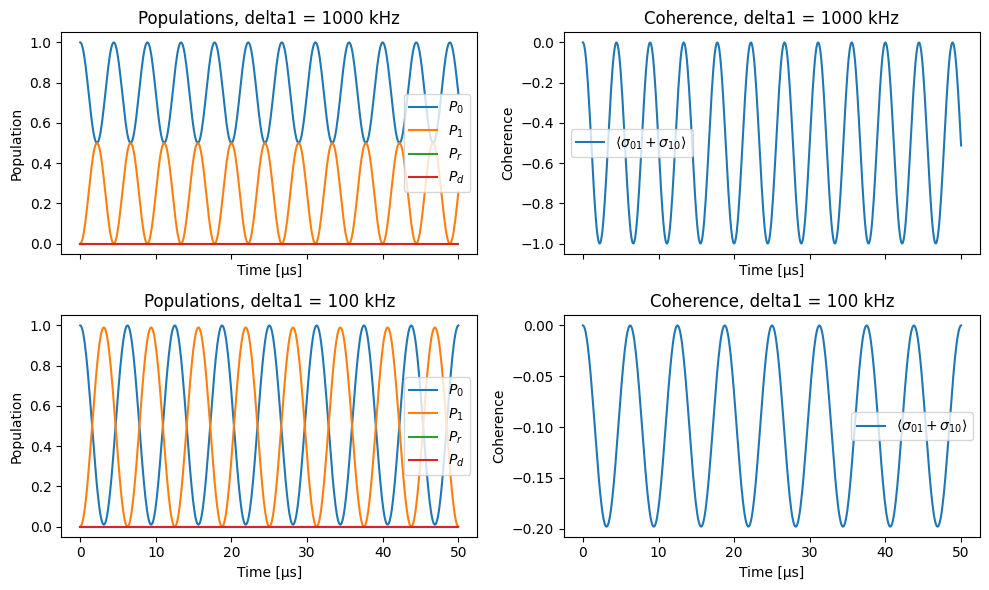

In [8]:
# 1) Define basic parameters and basis states

ket0 = basis(4, 0)  # |0>
ket1 = basis(4, 1)  # |1>
ketr = basis(4, 2)  # |r>
ketd = basis(4, 3)  # |d>

proj0 = ket0 * ket0.dag()  # |0><0|
proj1 = ket1 * ket1.dag()  # |1><1|
projr = ketr * ketr.dag()  # |r><r|
projd = ketd * ketd.dag()  # |d><d|

# Ladder ops between 0 and 1
sig01 = ket0 * ket1.dag()  # |0><1|
sig10 = ket1 * ket0.dag()  # |1><0|

# Coherence operator between |0> and |1>:
#    |0><1| + |1><0|
coherence_op = sig01 + sig10

# 2) Physical parameters
Omega01 = 1.0e6      # Hz  (i.e. 1 MHz)
delta1_scenarios = [1.0e6, 1.0e5]  # [1 MHz, 100 kHz]

# Rydberg decay parameters
gamma_r = 1.0 / (5.0e-6)  # 1/(5 microseconds)
b0r = 1.0/16.0
b1r = 1.0/16.0
bdr = 7.0/8.0

# 3) Build the collapse operators
c_ops = []
c_ops.append( np.sqrt(b0r * gamma_r) * (ket0 * ketr.dag()) )
c_ops.append( np.sqrt(b1r * gamma_r) * (ket1 * ketr.dag()) )
c_ops.append( np.sqrt(bdr * gamma_r) * (ketd * ketr.dag()) )

# 4) Time evolution setup
t_max = 50e-6
n_points = 500
t_list = np.linspace(0, t_max, n_points)

# Initial state: |0>
psi0 = ket0*ket0.dag()

# Expectation value operators
e_ops = [proj0, proj1, projr, projd, coherence_op]

# 5) Solve for each scenario
fig, axes = plt.subplots(2, 2, figsize=(10,6), sharex=True)

for i, delta1 in enumerate(delta1_scenarios):

    H = (0.5 * Omega01 * coherence_op) + (delta1 * proj1)

    # Solve the master equation
    result = mesolve(H, psi0, t_list, c_ops, e_ops)

    # Extract expectation values
    p0 = result.expect[0]       # <|0><0|
    p1 = result.expect[1]       # <|1><1|
    pr = result.expect[2]       # <|r><r|
    pd = result.expect[3]       # <|d><d|
    coh = result.expect[4]      # <|0><1| + |1><0|

    # Plot populations
    ax_pop = axes[i, 0]
    ax_pop.plot(t_list*1e6, p0, label=r'$P_0$')
    ax_pop.plot(t_list*1e6, p1, label=r'$P_1$')
    ax_pop.plot(t_list*1e6, pr, label=r'$P_r$')
    ax_pop.plot(t_list*1e6, pd, label=r'$P_d$')
    ax_pop.set_title(f"Populations, delta1 = {delta1/1e3:.0f} kHz")
    ax_pop.set_xlabel('Time [µs]')
    ax_pop.set_ylabel('Population')
    ax_pop.legend()

    # Plot coherence
    ax_coh = axes[i, 1]
    ax_coh.plot(t_list*1e6, coh, label=r'$\langle \sigma_{01} + \sigma_{10}\rangle$')
    ax_coh.set_title(f"Coherence, delta1 = {delta1/1e3:.0f} kHz")
    ax_coh.set_xlabel('Time [µs]')
    ax_coh.set_ylabel('Coherence')
    ax_coh.legend()

plt.tight_layout()
plt.show()

For 𝛿1 = 1MHz: The effective Rabi frequency Ωeff is larger (Ωeff=sqaureroot((1MHz)^2+(1MHz)^2)≈1.41MHz) and The population and coherence will oscillate faster and with a reduced amplitude of ∣0⟩↔∣1⟩ transfer (due to the detuning). For 𝛿1 = 100KHz: The detuning is smaller and Ωeff is: Ωeff=sqaureroot((1MHz)^2+(0.1MHz)^2)≈1.005MHz and We’ll see the coherence remain higher for longer times (less destructive detuning effect).

As for the δ1(t) not equal to 0 and equal to 0 comparison. In 1st case: We'll see incomplete oscillation (i.e., we never reach exactly 100% population in ∣1⟩ if 𝛿1 is large) and also we see changing coherence whereas in 2nd case there is complete oscillation and coherence.

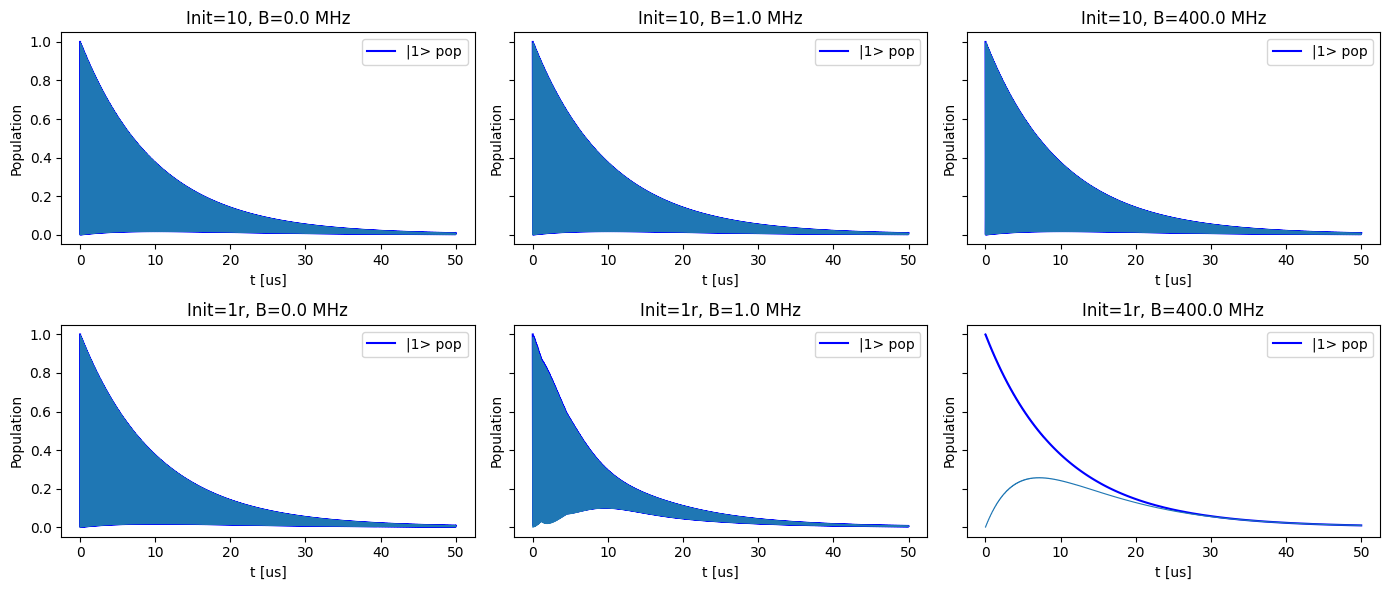

In [10]:
# 1) Define single-atom basis states
ket0 = basis(4, 0)   # |0>
ket1 = basis(4, 1)   # |1>
ketr = basis(4, 2)   # |r>
ketd = basis(4, 3)   # |d>

# Projectors (single atom)
Pj0 = ket0*ket0.dag()
Pj1 = ket1*ket1.dag()
Pr  = ketr*ketr.dag()
Pd  = ketd*ketd.dag()

sigma_1r = ket1*ketr.dag()  # |1><r|
sigma_r1 = ketr*ket1.dag()  # |r><1|

# 2) Tensor operators for two atoms
I4 = Qobj(np.eye(4))  # 4x4 Identity

# Single-atom operators for qubit 0 (tensored with identity on qubit 1)
sigma_1r_0 = tensor(sigma_1r, I4)
sigma_r1_0 = tensor(sigma_r1, I4)
Pr_0       = tensor(Pr, I4)
Pj1_0      = tensor(Pj1, I4)
Pj0_0      = tensor(Pj0, I4)

# Single-atom operators for qubit 1 (tensored with identity on qubit 0)
sigma_1r_1 = tensor(I4, sigma_1r)
sigma_r1_1 = tensor(I4, sigma_r1)
Pr_1       = tensor(I4, Pr)
Pj1_1      = tensor(I4, Pj1)
Pj0_1      = tensor(I4, Pj0)

twopi = 2*np.pi
MHz   = 1e6

# 3) Define system parameters
Omega_r_0 = twopi*10*MHz  # MHz (drive on qubit 0)
Omega_r_1 = 0.0   # MHz (no drive on qubit 1)
B_vals = [0.0,
          twopi*1*MHz,     # 1 MHz blockade (rad/s)
          twopi*400*MHz]   # 400 MHz blockade (rad/s)

# For Lindblad
gamma_r = 1.0/(5.0e-6)  # 1/(5 microseconds) => 2e5 1/s
b0r = 1.0/16.0
b1r = 1.0/16.0
bdr = 7.0/8.0

# 4) Build Hamiltonian
#    H_single(0) = (Omega_r_0 / 2) (|1><r| + |r><1|)
#    H_single(1) = 0
#    H_blockade  = B * |rr><rr|
def two_atom_hamiltonian(B):
    # Single-atom Hamiltonian for qubit 0
    H0 = (Omega_r_0/2.0) * (sigma_1r_0 + sigma_r1_0)
    # Single-atom Hamiltonian for qubit 1 is zero
    H1 = Qobj(np.zeros((16,16)), dims=[[4, 4], [4, 4]])  # 16x16 zero operator
    # Rydberg blockade term
    # The projector onto |r0, r1> is Pr_0 * Pr_1
    Hblock = B * (Pr_0 * Pr_1)
    return H0 + H1 + Hblock

# 5) Build the collapse operators
#    For each atom i, we have:
#    c0r_i = sqrt(gamma_r * b0r) * (|0><r|) [tensored with identity on other atom]
#    c1r_i = sqrt(gamma_r * b1r) * (|1><r|)
#    cdr_i = sqrt(gamma_r * bdr) * (|d><r|)
def build_c_ops(gamma_r, b0r, b1r, bdr):
    # Single-atom collapses for qubit 0
    c0r_0 = np.sqrt(gamma_r*b0r) * tensor(ket0*ketr.dag(), I4)
    c1r_0 = np.sqrt(gamma_r*b1r) * tensor(ket1*ketr.dag(), I4)
    cdr_0 = np.sqrt(gamma_r*bdr) * tensor(ketd*ketr.dag(), I4)

    # Single-atom collapses for qubit 1
    c0r_1 = np.sqrt(gamma_r*b0r) * tensor(I4, ket0*ketr.dag())
    c1r_1 = np.sqrt(gamma_r*b1r) * tensor(I4, ket1*ketr.dag())
    cdr_1 = np.sqrt(gamma_r*bdr) * tensor(I4, ketd*ketr.dag())

    c_ops_list = []
    if gamma_r != 0.0:
        c_ops_list = [c0r_0, c1r_0, cdr_0,
                      c0r_1, c1r_1, cdr_1]
    return c_ops_list

# 6) Time evolution parameters
tmax_us = 50.0  # 50 microseconds total
dt_us   = 0.01
tlist   = np.linspace(0, tmax_us, int(tmax_us/dt_us)+1) * 1e-6

# 7) Define some initial states to explore
initial_states = {
    '10': tensor(ket1, ket0),  # |1,0>
    '1r': tensor(ket1, ketr),  # |1,r>
    '00': tensor(ket0, ket0),  # etc...
    '0r': tensor(ket0, ketr)
}

# 8) Run the simulation for different B and different initial states
def run_simulation(init_label='10', B=0.0, gamma_r=gamma_r):
    # Hamiltonian
    H = two_atom_hamiltonian(B)
    # Collapses
    c_ops = build_c_ops(gamma_r, b0r, b1r, bdr)
    # Initial state
    psi0 = initial_states[init_label]
    # Solve
    result = mesolve(H, psi0, tlist, c_ops,
                     e_ops=[Pj1_0, Pr_0])
    # result expects a list of e_ops => we get a list of expectation values
    pop_ket1_0 = result.expect[0]  # population of |1> in qubit 0
    pop_r_0  = result.expect[1]  # population of |r> in qubit 0
    return pop_ket1_0, pop_r_0

# Example usage
# -------------
colors = ['r','g','b']
init_list = ['10', '1r']
fig, axs = plt.subplots(2, len(B_vals), figsize=(14,6), sharey=True)

for i, init_st in enumerate(init_list):
    for j, Bval in enumerate(B_vals):
        pop_ket1_0, pop_r_0 = run_simulation(init_st, Bval)
        axs[i,j].plot(tlist*1e6, pop_ket1_0, label='|1> pop', color='blue')
        axs[i,j].plot(tlist*1e6, pop_r_0, lw=0.8)
        B_MHz = Bval / (2*np.pi*1e6)   # show in MHz
        axs[i,j].set_title(f"Init={init_st}, B={B_MHz:.1f} MHz")
        axs[i,j].set_xlabel("t [us]")
        axs[i,j].set_ylabel("Population")
        axs[i,j].legend()

plt.tight_layout()
plt.show()

Init=|10>, B=0 MHz:
  P1 min/max: 8.096411906588801e-10 1.0
  Pr min/max: 0.0 0.999999999190359
Init=|10>, B=0 MHz:
  P1 min/max: 8.096411906588801e-10 1.0
  Pr min/max: 0.0 0.999999999190359
Init=|10>, B=0 MHz:
  P1 min/max: 8.096411906588801e-10 1.0
  Pr min/max: 0.0 0.999999999190359
Init=|10>, B=0 MHz:
  P1 min/max: 8.096411906588801e-10 1.0
  Pr min/max: 0.0 0.999999999190359
Init=|10>, B=0 MHz:
  P1 min/max: 0.009926396461181722 1.0
  Pr min/max: 0.0 0.9900736035388182
Init=|10>, B=0 MHz:
  P1 min/max: 0.9993842986380709 1.0
  Pr min/max: 0.0 0.0006157013619294242


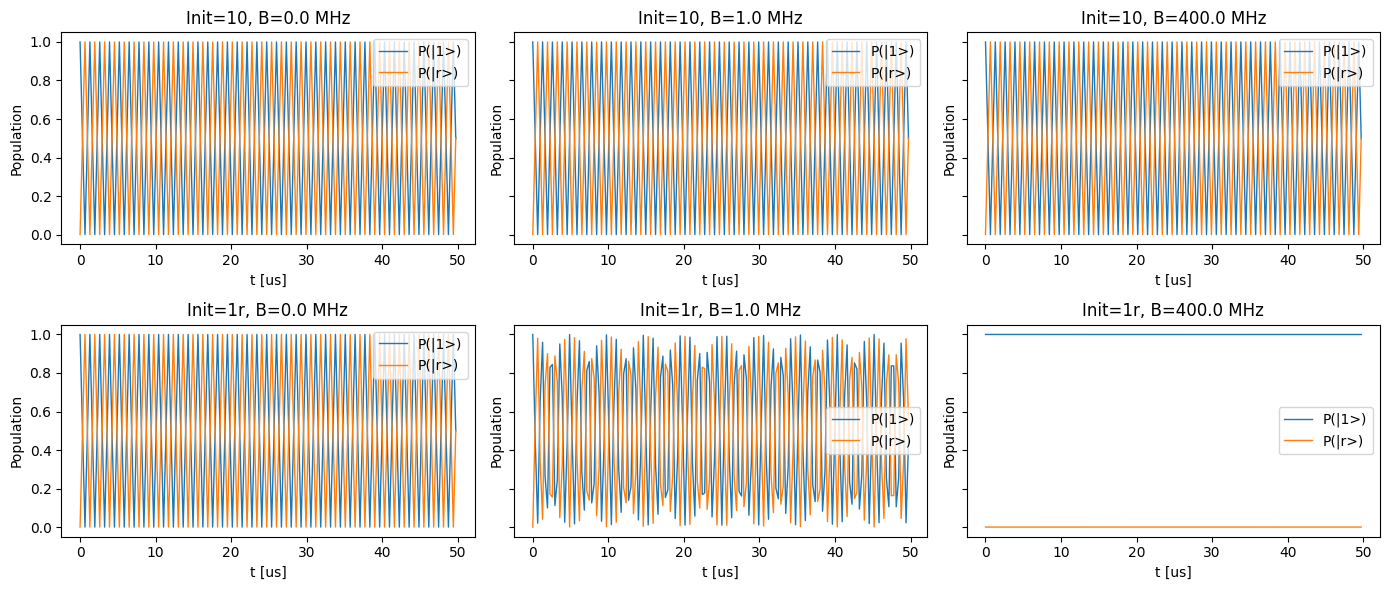

In [5]:
# 1) Define single-atom basis states
ket0 = basis(4, 0)   # |0>
ket1 = basis(4, 1)   # |1>
ketr = basis(4, 2)   # |r>
ketd = basis(4, 3)   # |d>

# Projectors (single atom)
Pj0 = ket0*ket0.dag()
Pj1 = ket1*ket1.dag()
Pr  = ketr*ketr.dag()
Pd  = ketd*ketd.dag()

sigma_1r = ket1*ketr.dag()  # |1><r|
sigma_r1 = ketr*ket1.dag()  # |r><1|

# 2) Tensor operators for two atoms
I4 = Qobj(np.eye(4))  # 4x4 Identity

# Single-atom operators for qubit 0 (tensored with identity on qubit 1)
sigma_1r_0 = tensor(sigma_1r, I4)
sigma_r1_0 = tensor(sigma_r1, I4)
Pr_0       = tensor(Pr, I4)
Pj1_0      = tensor(Pj1, I4)
Pj0_0      = tensor(Pj0, I4)

# Single-atom operators for qubit 1 (tensored with identity on qubit 0)
sigma_1r_1 = tensor(I4, sigma_1r)
sigma_r1_1 = tensor(I4, sigma_r1)
Pr_1       = tensor(I4, Pr)
Pj1_1      = tensor(I4, Pj1)
Pj0_1      = tensor(I4, Pj0)

twopi = 2*np.pi
MHz   = 1e6

# 3) Define system parameters
Omega_r_0 = twopi*10*MHz  # MHz (drive on qubit 0)
Omega_r_1 = 0.0   # MHz (no drive on qubit 1)
B_vals = [0.0,
          twopi*1*MHz,     # 1 MHz blockade (rad/s)
          twopi*400*MHz]   # 400 MHz blockade (rad/s)

# For Lindblad
gamma_r = 0.0
b0r = 1.0/16.0
b1r = 1.0/16.0
bdr = 7.0/8.0

# 4) Build Hamiltonian
#    H_single(0) = (Omega_r_0 / 2) (|1><r| + |r><1|)
#    H_single(1) = 0
#    H_blockade  = B * |rr><rr|
def two_atom_hamiltonian(B):
    # Single-atom Hamiltonian for qubit 0
    H0 = (Omega_r_0/2.0) * (sigma_1r_0 + sigma_r1_0)
    # Single-atom Hamiltonian for qubit 1 is zero
    H1 = Qobj(np.zeros((16,16)), dims=[[4, 4], [4, 4]])  # 16x16 zero operator
    # Rydberg blockade term
    # The projector onto |r0, r1> is Pr_0 * Pr_1
    Hblock = B * (Pr_0 * Pr_1)
    return H0 + H1 + Hblock

# 5) Build the collapse operators
#    For each atom i, we have:
#    c0r_i = sqrt(gamma_r * b0r) * (|0><r|) [tensored with identity on other atom]
#    c1r_i = sqrt(gamma_r * b1r) * (|1><r|)
#    cdr_i = sqrt(gamma_r * bdr) * (|d><r|)
def build_c_ops(gamma_r, b0r, b1r, bdr):
    # Single-atom collapses for qubit 0
    c0r_0 = np.sqrt(gamma_r*b0r) * tensor(ket0*ketr.dag(), I4)
    c1r_0 = np.sqrt(gamma_r*b1r) * tensor(ket1*ketr.dag(), I4)
    cdr_0 = np.sqrt(gamma_r*bdr) * tensor(ketd*ketr.dag(), I4)

    # Single-atom collapses for qubit 1
    c0r_1 = np.sqrt(gamma_r*b0r) * tensor(I4, ket0*ketr.dag())
    c1r_1 = np.sqrt(gamma_r*b1r) * tensor(I4, ket1*ketr.dag())
    cdr_1 = np.sqrt(gamma_r*bdr) * tensor(I4, ketd*ketr.dag())

    c_ops_list = []
    if gamma_r != 0.0:
        c_ops_list = [c0r_0, c1r_0, cdr_0,
                      c0r_1, c1r_1, cdr_1]
    return c_ops_list

# 6) Time evolution parameters
tmax_us = 50.0  # 50 microseconds total
dt_us   = 0.013
tlist  = np.arange(0.0, tmax_us + 1e-6, dt_us) * 1e-6

# 7) Define some initial states to explore
initial_states = {
    '10': tensor(ket1, ket0),  # |1,0>
    '1r': tensor(ket1, ketr),  # |1,r>
    '00': tensor(ket0, ket0),  # etc...
    '0r': tensor(ket0, ketr)
}

# 8) Run the simulation for different B and different initial states
def run_simulation(init_label='10', B=0.0, gamma_r=gamma_r):
    # Hamiltonian
    H = two_atom_hamiltonian(B)
    # Collapses
    c_ops = build_c_ops(gamma_r, b0r, b1r, bdr)
    # Initial state
    psi0 = initial_states[init_label]
    # Solve
    result = mesolve(H, psi0, tlist, c_ops,
                     e_ops=[Pj1_0, Pr_0])
    # result expects a list of e_ops => we get a list of expectation values
    pop_ket1_0 = result.expect[0]  # population of |1> in qubit 0
    pop_r_0  = result.expect[1]  # population of |r> in qubit 0
    return pop_ket1_0, pop_r_0

# Example usage
# -------------
colors = ['r','g','b']
init_list = ['10', '1r']
fig, axs = plt.subplots(2, len(B_vals), figsize=(14,6), sharey=True)

stride = 25                   # plot every 25th point
zoom_us = 2.0                 # optional: show first 2 µs clearly
for i, init_st in enumerate(init_list):
    for j, Bval in enumerate(B_vals):
        pop_ket1_0, pop_r_0 = run_simulation(init_st, Bval)
        print("Init=|10>, B=0 MHz:")
        print("  P1 min/max:", float(pop_ket1_0.min()), float(pop_ket1_0.max()))
        print("  Pr min/max:", float(pop_r_0.min()),  float(pop_r_0.max()))
        axs[i,j].plot((tlist*1e6)[::stride], pop_ket1_0[::stride], lw=1.0, label='P(|1>)', color='C0')
        axs[i,j].plot((tlist*1e6)[::stride], pop_r_0[::stride],  lw=1.0, label='P(|r>)', color='C1')
        B_MHz = Bval / (2*np.pi*1e6)   # show in MHz
        axs[i,j].set_title(f"Init={init_st}, B={B_MHz:.1f} MHz")
        axs[i,j].set_xlabel("t [us]")
        axs[i,j].set_ylabel("Population")
        axs[i,j].legend()

plt.tight_layout()
plt.show()

A) Same initial state, different blockade B
Init = ∣10⟩ (atom 1 in ∣0⟩)

Observation: Traces for B=0,1,400 MHz are essentially identical.

Reason: Atom 1 never reaches ∣r⟩, so the interaction term B∣rr⟩⟨rr∣ is never “on.” Atom 0 behaves like a single atom: damped Rabi

P∣r⟩0​​(t)≈e−t/τr​sin2(2Ωt​),P∣1⟩0​​(t)=1−P∣r⟩0​​(t)−leakage.

Init = ∣1r⟩ (atom 1 starts in ∣r⟩) B=0 MHz: normal driven oscillations (with decay) between ∣1r⟩ and ∣rr⟩
B=1 MHz (weak blockade): almost the same as
B=0; the relative detuning is small (B/Ω=0.1), so contrast ≈Ω^2/(Ω^2+B^2)≈0.99 and frequency Ωeff ≈ sqrt(Ω2+B2)≈1.005Ω.
B=400 MHz (strong blockade): while atom 1 remains in ∣r⟩, excitation of atom 0 is strongly suppressed:
P∣r⟩0​(early)​∼(BΩ​)2=(40010​)2≈6.25×10−4.
After ∼τr, atom 1 decays out of ∣r⟩, the blockade lifts, and atom 0 resumes the usual driven dynamics (“blockade-then-release”).

B) Same blockade B, different initial statesB=0 or 1 MHz: ∣10⟩ and
∣1r⟩ produce very similar damped oscillations (the latter is effectively the same dynamics but starting in the coupled manifold that includes ∣rr⟩).
B=400 MHz: large qualitative difference.
– With ∣10⟩ the curves are unchanged (blockade never engages).
– With ∣1r⟩ the early motion of atom 0 is frozen by blockade until the neighbor decays; only then do oscillations appear.


No-decay case (γr=0)
Run the same comparisons with the collapse operators removed.
Init = ∣10⟩ (any B): pure, undamped Rabi on atom 0

P∣r⟩0​​(t)=sin2(2Ωt​),P∣1⟩0​​(t)=cos2(2Ωt​),

still no dependence on
B because atom 1 never visits ∣r⟩.

Init = ∣1r⟩:

B=0 or 1 MHz: undamped oscillations with frequency Ωeff=Ω2+B2
and contrast Ω^2/Ω^eff2 (≈1 and ≈0.99, respectively).

B=400 MHz: ideal blockade—atom 0 remains in ∣1⟩ and P∣r⟩0(t)≈0 for the full time window (up to the small off-resonant leakage ∼(Ω/B)^2) because the neighbor never leaves ∣r⟩.